# 工作负载模式与请求到达过程示例

本 Notebook 用于演示 faas-sim 中请求生成器的基本用法。它重点展示两类概念：

1. **RPS profile**：描述某一时刻的目标平均请求速率，即每秒请求数如何随仿真时间变化。
2. **Arrival profile**：根据 RPS 曲线生成实际请求到达间隔，用于在仿真实验中产生更接近真实系统的请求序列。

该文件主要用于交互式观察负载曲线、验证工作负载生成逻辑，以及保存和复现请求到达轨迹。它不是完整的 faas-sim 仿真实验入口。


In [16]:
# 标准库：用于统计真实代码运行耗时，以及保存/读取预生成的请求轨迹。
import time
import pickle

# 第三方库：用于绘图、表格处理和离散事件仿真环境。
import matplotlib.pyplot as plt
import pandas as pd
import simpy

# faas-sim 请求生成模块：提供 RPS 曲线、请求到达间隔生成、轨迹保存和回放等工具函数。
from sim.requestgen import *

# Matplotlib 中文字体配置：用于解决 Notebook 绘图时中文标题、坐标轴、图例乱码或 Glyph missing 警告。
# 这里优先手动指定 Windows 常见中文字体文件。只要其中一个字体文件存在，就会注册并使用该字体。
from pathlib import Path
import matplotlib as mpl
import matplotlib.font_manager as fm


# Windows 常见中文字体路径。优先使用微软雅黑，其次使用黑体、宋体。
CHINESE_FONT_CANDIDATES = [
    Path(r"C:\Windows\Fonts\msyh.ttc"),      # 微软雅黑
    Path(r"C:\Windows\Fonts\msyhbd.ttc"),    # 微软雅黑加粗
    Path(r"C:\Windows\Fonts\simhei.ttf"),    # 黑体
    Path(r"C:\Windows\Fonts\simsun.ttc"),    # 宋体
    Path(r"C:\Windows\Fonts\simkai.ttf"),    # 楷体
]


def setup_chinese_font():
    """
    手动为 Matplotlib 注册并启用中文字体。

    作用：
    1. 从 CHINESE_FONT_CANDIDATES 中找到当前系统存在的中文字体文件；
    2. 将该字体注册到 Matplotlib 字体管理器；
    3. 设置 Matplotlib 全局字体，使后续绘图的标题、坐标轴、图例默认使用中文字体；
    4. 关闭 unicode minus 问题，避免负号显示为方块。
    """
    for font_path in CHINESE_FONT_CANDIDATES:
        if font_path.exists():
            # 将字体文件注册到 Matplotlib 当前会话中。
            fm.fontManager.addfont(str(font_path))

            # 基于字体文件创建字体属性对象，后续也可以显式传给 title/xlabel/ylabel/legend。
            font_prop = fm.FontProperties(fname=str(font_path))
            font_name = font_prop.get_name()

            # 设置全局字体。font.family 使用 sans-serif，再把中文字体放到 sans-serif 候选列表最前面。
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [
                font_name,
                "Microsoft YaHei",
                "SimHei",
                "SimSun",
                "KaiTi",
                "DejaVu Sans",
            ]

            # 解决中文字体下负号显示异常的问题。
            mpl.rcParams["axes.unicode_minus"] = False

            print(f"已启用 Matplotlib 中文字体：{font_name}，字体文件：{font_path}")
            return font_prop

    raise FileNotFoundError(
        "未找到可用中文字体。请检查 C:\\Windows\\Fonts 下是否存在 msyh.ttc、simhei.ttf 或 simsun.ttc。"
    )


# CHINESE_FONT_PROP 可用于在个别图中显式指定中文字体。
CHINESE_FONT_PROP = setup_chinese_font()


def apply_chinese_font(ax=None):
    """
    对已经创建好的 Matplotlib 图表对象显式应用中文字体。

    使用场景：
    如果全局 rcParams 已设置但某些标题、坐标轴或图例仍然回退到 DejaVu Sans，
    可以在绘图代码最后调用：
        apply_chinese_font()

    参数：
    ax: Matplotlib Axes 对象。默认使用当前坐标轴 plt.gca()。
    """
    if ax is None:
        ax = plt.gca()

    ax.title.set_fontproperties(CHINESE_FONT_PROP)
    ax.xaxis.label.set_fontproperties(CHINESE_FONT_PROP)
    ax.yaxis.label.set_fontproperties(CHINESE_FONT_PROP)

    for label in ax.get_xticklabels():
        label.set_fontproperties(CHINESE_FONT_PROP)

    for label in ax.get_yticklabels():
        label.set_fontproperties(CHINESE_FONT_PROP)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontproperties(CHINESE_FONT_PROP)

    return ax

已启用 Matplotlib 中文字体：Microsoft YaHei，字体文件：C:\Windows\Fonts\msyh.ttc


## RPS 曲线（RPS profiles）

RPS profile 用于在给定仿真时刻产生一个目标平均请求速率，单位通常是 requests per second。

下面的辅助函数会运行一个持续 `until` 秒的 SimPy 仿真环境，并且每隔 `time_step` 秒从 RPS profile 中采样一次。采样结果会用于绘制负载曲线，从而直观看到请求速率随仿真时间的变化。


In [17]:
def run_rps_profile(env, profile, until, time_step=0.5):
    """运行一个 RPS 曲线生成器，并返回采样得到的时间序列。

    参数说明：
    - env：SimPy 仿真环境，用于推进离散事件时间。
    - profile：RPS 生成器，每次 next(profile) 返回当前时刻的目标 RPS。
    - until：仿真运行到多少秒后结束。
    - time_step：采样间隔，默认每 0.5 秒采样一次。

    返回值：
    - x：采样时刻列表，对应 env.now。
    - y：每个采样时刻的目标 RPS。
    """
    # x 保存仿真时间，y 保存该时刻对应的目标 RPS。
    x = list()
    y = list()

    def generate_profile_data():
        """后台采样进程：周期性读取 RPS profile 并推进仿真时间。"""
        while True:
            # 从 profile 中取出当前时刻的目标请求速率。
            rps = next(profile)
            x.append(env.now)
            y.append(rps)

            # 挂起当前 SimPy 进程 time_step 秒，表示下一次采样发生在未来时刻。
            yield env.timeout(time_step)

    # 将采样逻辑注册为 SimPy 后台进程，然后运行仿真直到 until。
    env.process(generate_profile_data())
    env.run(until=until)

    return x, y


### 固定 RPS 曲线（constant profile）

固定 RPS 曲线会在整个仿真过程中保持相同的目标请求速率。下面的示例表示目标负载始终为 50 RPS。


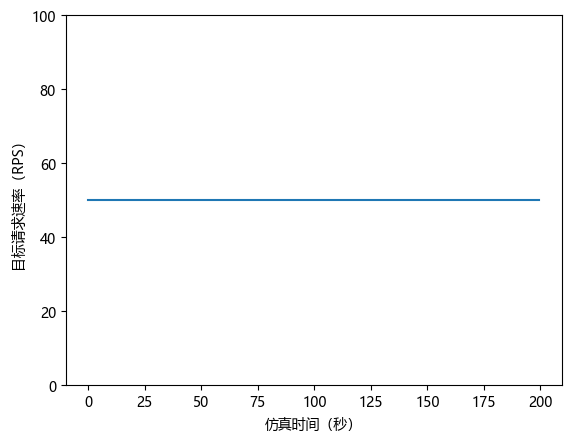

In [18]:
# 创建一个新的 SimPy 仿真环境。
env = simpy.Environment()

# 构造固定 RPS 曲线：整个仿真期间目标请求速率固定为 50。
profile = constant_rps_profile(50)

# 运行 200 秒并采样该曲线。
t, rps = run_rps_profile(env, profile, 200)

# 绘制 RPS 随仿真时间变化的曲线。
plt.plot(t, rps)
plt.ylim(0, 100)
plt.xlabel('仿真时间（秒）')
plt.ylabel('目标请求速率（RPS）')
plt.show()


### 正弦 RPS 曲线（sine profile）

正弦 RPS 曲线用于模拟周期性负载变化。

其中，`max_rps` 表示负载峰值，`period` 表示两个负载峰值之间相隔的仿真时间，单位为秒。


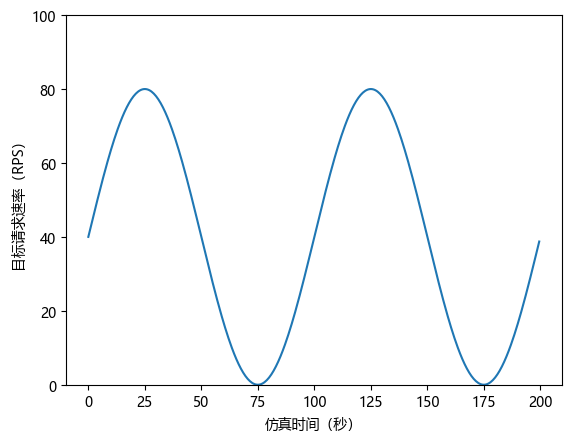

In [19]:
# 创建仿真环境。
env = simpy.Environment()

# 构造正弦负载曲线：峰值为 80 RPS，周期为 100 秒。
profile = sine_rps_profile(env, 80, period=100)

# 运行 200 秒，观察两个周期左右的负载变化。
t, rps = run_rps_profile(env, profile, 200)

plt.plot(t, rps)
plt.ylim(0, 100)
plt.xlabel('仿真时间（秒）')
plt.ylabel('目标请求速率（RPS）')
plt.show()


### 随机游走 RPS 曲线（random walk）

随机游走曲线用于模拟不稳定、随机波动的请求负载。

主要参数包括：

- `mu`：初始或中心 RPS 水平；
- `sigma`：随机波动强度，数值越大，曲线越容易出现尖峰和剧烈变化；
- `max_rps`：RPS 上限，超过该上限的采样值会被拒绝或截断。


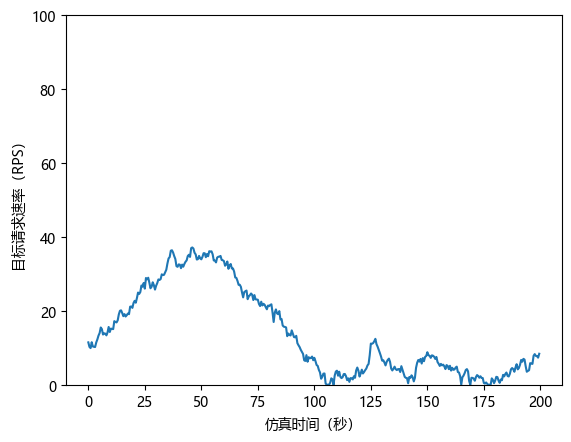

In [20]:
# 构造轻度波动的随机游走负载：sigma 较小，因此曲线相对平滑。
profile = randomwalk_rps_profile(mu=10, sigma=1, max_rps=100)

# 运行 200 秒并绘图。
t, rps = run_rps_profile(simpy.Environment(), profile, 200)
plt.plot(t, rps)
plt.ylim(0, 100)
plt.xlabel('仿真时间（秒）')
plt.ylabel('目标请求速率（RPS）')
plt.show()


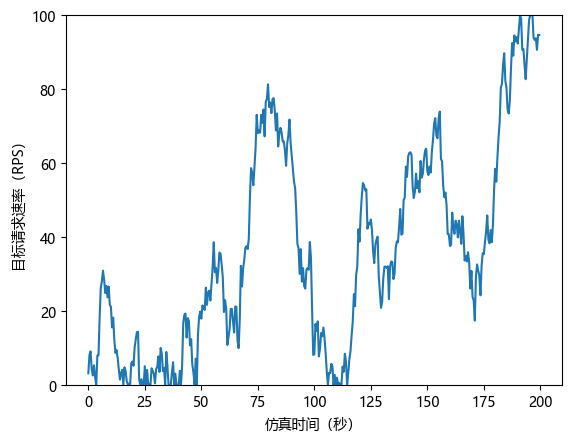

In [21]:
# 构造更剧烈波动的随机游走负载：sigma 增大后，RPS 曲线更容易出现突增和突降。
profile = randomwalk_rps_profile(mu=10, sigma=5, max_rps=100)

# 运行 200 秒并绘图。
t, rps = run_rps_profile(simpy.Environment(), profile, 200)
plt.plot(t, rps)
plt.ylim(0, 100)
plt.xlabel('仿真时间（秒）')
plt.ylabel('目标请求速率（RPS）')
plt.show()


## 请求到达曲线（Arrival profiles）

RPS profile 只描述目标平均速率，而实际仿真实验需要知道“下一次请求何时到达”。

Arrival profile 会对 RPS profile 进行包装，将目标 RPS 转换为请求间隔 inter-arrival time。这样可以生成更接近真实系统的请求到达过程，而不是简单地按固定间隔发送请求。

下面的辅助函数会运行 `until` 秒仿真，并返回一个 DataFrame。每条记录包含：

- `simtime`：当前请求到达时的仿真时间；
- `ia`：当前请求到下一次请求之间的时间间隔。


In [22]:
def run_arrival_profile(env, ia_gen, until):
    """运行请求到达间隔生成器，并返回请求到达轨迹表。

    参数说明：
    - env：SimPy 仿真环境。
    - ia_gen：请求间隔生成器，每次 next(ia_gen) 返回下一次请求到达前需要等待的秒数。
    - until：仿真运行到多少秒后结束。

    返回值：
    - df：pandas DataFrame，包含请求到达时刻 simtime 和请求间隔 ia。
    """
    # x 保存请求到达时刻，y 保存相邻两次请求之间的时间间隔。
    x = list()
    y = list()

    def event_generator():
        """后台事件生成进程：根据请求间隔不断产生请求到达事件。"""
        while True:
            # 获取下一次请求到达前需要等待的时间。
            ia = next(ia_gen)
            x.append(env.now)
            y.append(ia)

            # 等待 ia 秒后，进入下一次请求到达时刻。
            yield env.timeout(ia)

    # 记录真实墙钟时间，用于观察生成大量请求事件时的代码执行开销。
    then = time.time()

    # 注册请求事件生成进程，并推进仿真时间。
    env.process(event_generator())
    env.run(until=until)

    print('生成并仿真 %d 个请求事件耗时 %.2f 秒' % (len(x), time.time() - then))

    # 将仿真秒数转换成 DatetimeIndex，方便后续使用 pandas 的 rolling 窗口统计。
    df = pd.DataFrame(
        data={'simtime': x, 'ia': y},
        index=pd.DatetimeIndex(pd.to_datetime(x, unit='s', origin='unix'))
    )
    return df


### 固定 RPS 下的随机到达过程

下面示例先构造 20 RPS 的固定目标负载，再使用指数分布请求到达模型生成具体请求间隔。

`expovariate_arrival_profile` 的作用是：在平均速率符合目标 RPS 的前提下，让请求到达间隔具有随机性，从而更接近常见的泊松到达过程。


生成并仿真 71985 个请求事件耗时 0.25 秒


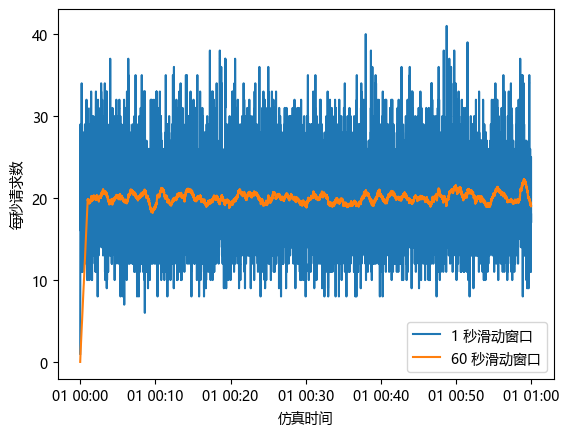

In [23]:
# 使用固定 20 RPS 作为平均负载，并通过指数分布生成请求间隔。
profile = expovariate_arrival_profile(constant_rps_profile(rps=20))

# 生成 1 小时仿真时间内的请求到达轨迹。
df = run_arrival_profile(simpy.Environment(), profile, until=3600)

# rolling('1s').count()：统计每 1 秒窗口内的请求数，反映瞬时波动。
x1 = df['ia'].rolling('1s').count()

# rolling('60s').count() / 60：统计 60 秒窗口内的平均 RPS，曲线更平滑。
x2 = df['ia'].rolling('60s').count() / 60

plt.plot(x1, label='1 秒滑动窗口')
plt.plot(x2, label='60 秒滑动窗口')
plt.ylabel('每秒请求数')
plt.xlabel('仿真时间')
plt.legend()
plt.show()


### 变化 RPS 下的请求到达过程

当某些 RPS profile 可能下降到 0 时，需要设置 `max_ia` 作为保护值。

原因是请求间隔通常可近似理解为 `ia = 1 / rps`。如果 `rps == 0`，直接计算会产生数学错误或无限等待。

因此，`max_ia` 表示允许的最长请求间隔。例如 `max_ia=120` 表示两次请求之间最长间隔不超过 120 秒。


生成并仿真 36417 个请求事件耗时 0.15 秒


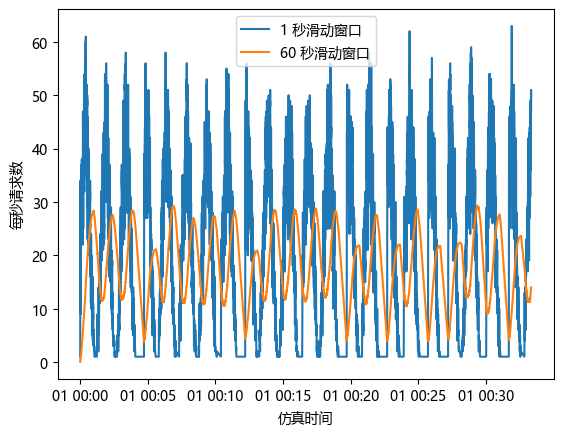

In [24]:
# 创建仿真环境。
env = simpy.Environment()

# 正弦负载可能接近 0，因此通过 max_ia 限制最大请求间隔。
profile = expovariate_arrival_profile(
    sine_rps_profile(env, max_rps=40, period=90),
    max_ia=35
)

# 生成 2000 秒内的请求到达轨迹。
df = run_arrival_profile(env, profile, until=2000)

# 分别计算短窗口和长窗口下的观测 RPS。
x1 = df['ia'].rolling('1s').count()
x2 = df['ia'].rolling('60s').count() / 60

plt.plot(x1, label='1 秒滑动窗口')
plt.plot(x2, label='60 秒滑动窗口')
plt.ylabel('每秒请求数')
plt.xlabel('仿真时间')
plt.legend()
plt.show()


### 设置时间坐标格式的绘图示例

下面示例展示如何使用 `matplotlib.dates` 调整横轴时间刻度。该写法适合在论文实验预分析中快速观察请求速率是否符合预期。


生成并仿真 99627 个请求事件耗时 0.35 秒


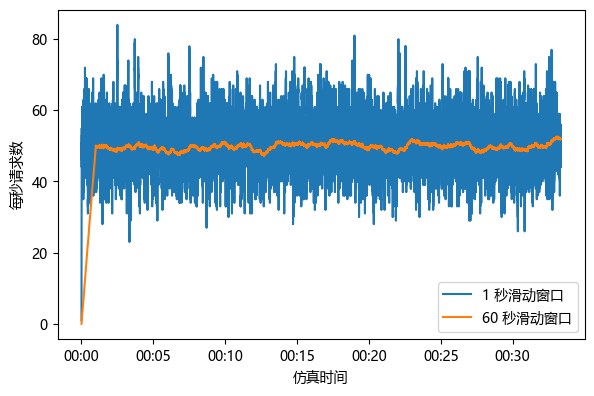

In [25]:
# matplotlib.dates 用于控制时间类型横轴的刻度和显示格式。
import matplotlib.dates as dates

# 创建图对象。
fig, axs = plt.subplots(1, 1, figsize=(6.8, 4.27))

# 生成固定 50 RPS 的随机请求到达过程。
env = simpy.Environment()
profile = expovariate_arrival_profile(constant_rps_profile(50))
df = run_arrival_profile(env, profile, until=2000)

# 计算 1 秒窗口与 60 秒窗口下的请求速率。
x1 = df['ia'].rolling('1s').count()
x2 = df['ia'].rolling('60s').count() / 60

plt.plot(x1, label='1 秒滑动窗口')
plt.plot(x2, label='60 秒滑动窗口')

# 设置横轴主刻度位置和显示格式。
plt.gca().xaxis.set_major_locator(
    dates.MinuteLocator(byminute=[0, 5, 10, 15, 20, 25, 30, 45], interval=1)
)
plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%H:%M'))

plt.ylabel('每秒请求数')
plt.xlabel('仿真时间')
plt.legend()
plt.show()


### 正弦负载下的请求到达过程

下面示例将正弦 RPS 曲线和指数分布到达过程结合起来，用于模拟具有周期性变化且请求间隔随机的工作负载。


生成并仿真 100164 个请求事件耗时 0.43 秒


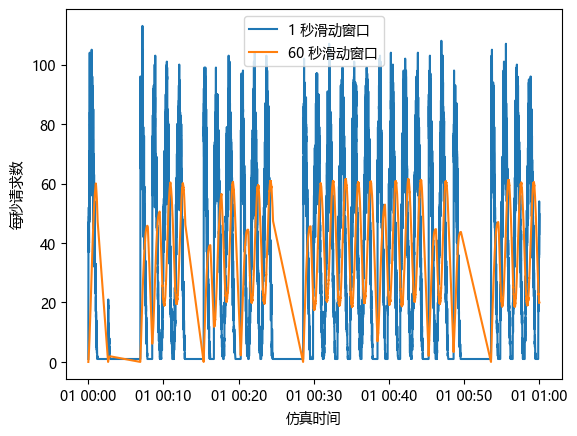

In [26]:
# 构造正弦变化的目标 RPS，并使用指数分布生成真实请求间隔。
env = simpy.Environment()
profile = expovariate_arrival_profile(
    sine_rps_profile(env, 80, period=100),
    max_ia=240
)

# 生成 1 小时仿真时间内的请求到达轨迹。
df = run_arrival_profile(env, profile, until=3600)

# 短窗口显示瞬时波动，长窗口显示平滑后的平均趋势。
x1 = df['ia'].rolling('1s').count()
x2 = df['ia'].rolling('60s').count() / 60

plt.plot(x1, label='1 秒滑动窗口')
plt.plot(x2, label='60 秒滑动窗口')
plt.ylabel('每秒请求数')
plt.xlabel('仿真时间')
plt.legend()
plt.show()


# 保存与回放请求轨迹（Save and replay profile）

在可复现实验中，最好将一次生成的请求间隔序列保存下来。这样后续不同调度策略、缓存策略或伸缩策略可以使用完全相同的请求轨迹，避免因为随机负载不同而影响对比公平性。

第一步是使用 profile 生成函数创建一个请求到达模型。可以手动传入 `Environment`，也可以让 `save_requests` 创建默认的 SimPy 仿真环境。


In [27]:
# 定义一个 profile 工厂函数。
# 这里使用正弦 RPS + 指数分布到达间隔，表示周期性波动且具有随机性的请求负载。
profile = lambda env: expovariate_arrival_profile(
    sine_rps_profile(env, 80, period=100),
    max_ia=240
)

# 保存请求轨迹的文件路径。
import os
import sys
file_dir = os.path.dirname(sys.argv[0])
file = file_dir + '/exp_profile.pkl'

# 生成 duration=100 秒内的请求间隔序列，并写入 pickle 文件。
save_requests(profile, duration=100, file=file)

# 读取并打印前 5 个请求间隔，确认轨迹文件已经生成。
with open(file, 'rb') as fd:
    print(pickle.load(fd)[:5])


simulating 4029 events took 0.02 sec
[0.02596246885420162, 0.010946969479423588, 0.061225603650525914, 0.014400671083386806, 0.011348630603283678]


保存完成后，可以使用 `pre_recorded_profile` 将已有轨迹文件重新加载为请求间隔生成器。

这种方式适合论文实验中的多策略公平对比：所有策略使用同一份请求到达序列，只改变调度、缓存或伸缩算法。


生成并仿真 4029 个请求事件耗时 0.01 秒


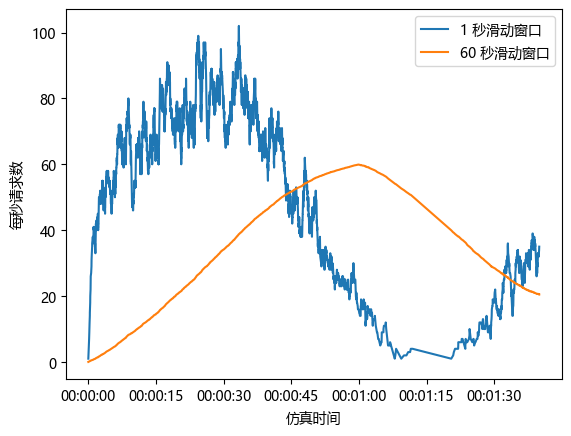

In [28]:
# 从文件中加载预先保存的请求间隔序列。
profile = pre_recorded_profile(file)

# 使用预录制轨迹运行 100 秒仿真。
df = run_arrival_profile(simpy.Environment(), profile, until=100)

# 统计并绘制不同时间窗口下的请求速率。
x1 = df['ia'].rolling('1s').count()
x2 = df['ia'].rolling('60s').count() / 60

plt.plot(x1, label='1 秒滑动窗口')
plt.plot(x2, label='60 秒滑动窗口')
plt.ylabel('每秒请求数')
plt.xlabel('仿真时间')
plt.legend()
plt.show()
